# MPS assumptions test

Created: 10-06-2026

Objectives:

Compare what we're finding in [this notebook](quspin_zxz_y_defects.ipynb) to the MPS case.

# Package imports

In [3]:
import sys
sys.path.append('../../')

In [4]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

In [ ]:
from tqdm import tqdm

In [ ]:
import quimb as qu
import quimb.tensor as qtn

In [ ]:
#from SPTOptimization.Optimizers.utils import to_npc_array

# Load data

In [ ]:
DATA_DIR = r"../../data/y_transverse_cluster_100_site_dmrg"

In [ ]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
    with h5py.File(f_name, 'r') as f:
        data = hdf5_io.load_from_hdf5(f)
        loaded_data.append(data)

In [ ]:
b_parameters = sorted(list(d['paramters']['t'] for d in loaded_data))

In [ ]:
psi_dict = dict()

In [ ]:
for b in b_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data
        if d['paramters']['t'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = quimb_psi

# Testing

In [1]:
len(loaded_data)

NameError: name 'loaded_data' is not defined

In [2]:
num_psi_sites = 100

In [54]:
num_symmetry_sites = 8
leftmost_symmetry_site = (num_psi_sites//2) - (num_symmetry_sites//2)
rightmost_symmetry_site = leftmost_symmetry_site + num_symmetry_sites - 1
symmetry_sites = list(range(
    leftmost_symmetry_site,
    rightmost_symmetry_site+1
))

In [55]:
tenpy_psi = loaded_data[8]['wavefunction']

In [56]:
b=0.8

tenpy_psi = next(
    d['wavefunction']
    for d in loaded_data
    if d['paramters']['t'] == 0.8
)

In [59]:
psi_arrays = list()
psi_arrays.append(
    mps_psi.get_B(leftmost_symmetry_site, 'B').to_ndarray()
)
for i in symmetry_sites[1:-1]:
    psi_arrays.append(
        mps_psi.get_B(i, 'B')
        .to_ndarray()
    )
psi_arrays.append(
    mps_psi.get_B(rightmost_symmetry_site, 'G')
    .to_ndarray()
)

quimb_psi = (
    qtn
    .tensor_1d
    .MatrixProductState(psi_arrays, shape='lpr')
)

In [60]:
quimb_psi

MatrixProductState(tensors=8, indices=16, L=8, max_bond=16)

In [63]:
sub_psi = quimb_psi.copy()

In [65]:
sub_psi.tensors[0] = sub_psi.tensors[0][0, ...]

TypeError: 'Tensor' object is not subscriptable

In [66]:
sub_array_l = psi_arrays[0][0, ...]
sub_array_r = psi_arrays[0][..., 0]
inner_psi_arrays = psi_arrays[1:-1]

sub_arrays = [
    sub_array_l,
    *inner_psi_arrays,
    sub_array_r
]

sub_psi = (
    qtn
    .tensor_1d
    .MatrixProductState(sub_arrays, shape='lpr')
)

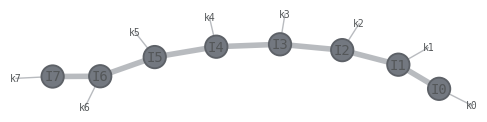

In [67]:
sub_psi.draw()

Generate effective density matrix for psi.

In [70]:
q_top = sub_psi.copy(deep=True)

In [71]:
for i in range(num_symmetry_sites):
    q_top[i].modify(data=q_top[i].data.conj())
    q_top.gate(
        np_X,
        where=i,
        contract=False,
        inplace=True
    )

In [72]:
num_defect_sites = 2

In [73]:
left_defect_sites = [0,1]
right_defect_sites = [6,7]

In [75]:
indices_to_map = left_defect_sites + right_defect_sites
index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

In [78]:
index_mapping

{'k0': 'b0', 'k1': 'b1', 'k6': 'b6', 'k7': 'b7'}

In [76]:
q_bottom = (
    sub_psi
    .copy()
    .reindex(index_mapping, inplace=True)
    .conj()
)

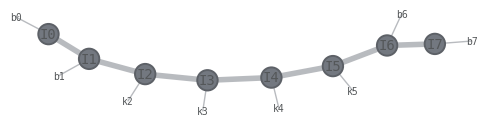

In [79]:
q_bottom.draw()

In [80]:
tn = (q_top & q_bottom)

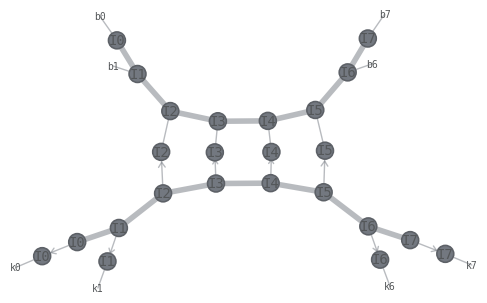

In [81]:
tn.draw()

In [82]:
tnc = tn.contract()

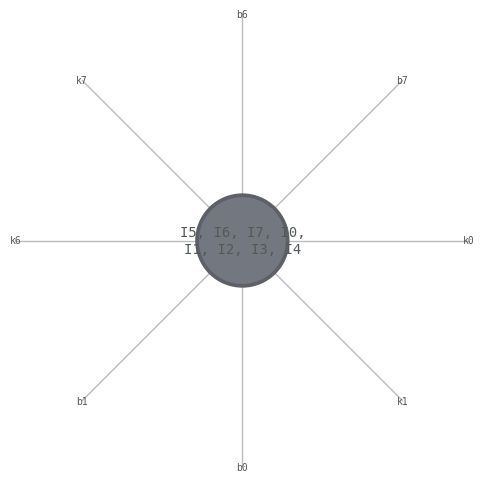

In [83]:
tnc.draw()

In [84]:
fuse_maps = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites)),
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]

In [85]:
tnc.fuse(fuse_maps, inplace=True)

Tensor(shape=(4, 4, 4, 4), inds=('k_left', 'b_left', 'k_right', 'b_right'), tags=oset(['I5', 'I6', 'I7', 'I0', 'I1', 'I2', 'I3', 'I4']))

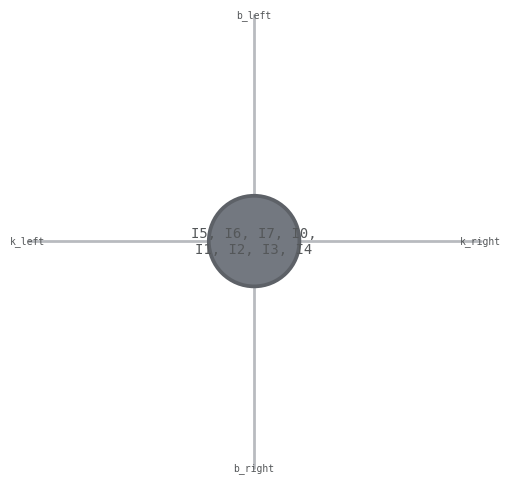

In [87]:
tnc.draw()

In [88]:
help(tnc.tensor_split)

AttributeError: 'Tensor' object has no attribute 'tensor_split'

In [89]:
help(qtn.tensor_core.tensor_split)

Help on function tensor_split in module quimb.tensor.tensor_core:

tensor_split(T: 'Tensor', left_inds, method='svd', get=None, absorb='both', max_bond=None, cutoff=1e-10, cutoff_mode='rel', renorm=None, ltags=None, rtags=None, stags=None, bond_ind=None, right_inds=None, matrix_svals=False)
    Decompose this tensor into two tensors.
    
    Parameters
    ----------
    T : Tensor or TNLinearOperator
        The tensor (network) to split.
    left_inds : str or sequence of str
        The index or sequence of inds, which ``T`` should already have, to
        split to the 'left'. You can supply ``None`` here if you supply
        ``right_inds`` instead.
    method : str, optional
        How to split the tensor, only some methods allow bond truncation:
    
        - ``'svd'``: full SVD, allows truncation.
        - ``'eig'``: full SVD via eigendecomp, allows truncation.
        - ``'lu'``: full LU decomposition, allows truncation. This method
          favors tensor sparsity but is n

In [91]:
split_t = qtn.tensor_core.tensor_split(
    tnc,
    left_inds = ['k_left', 'b_left'],
    absorb=None
)

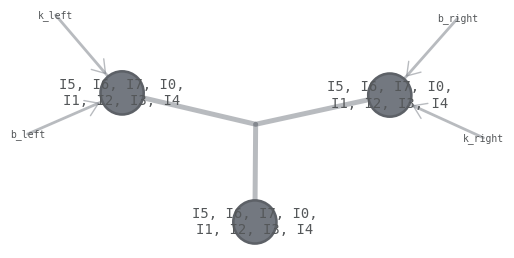

In [92]:
split_t.draw()

In [95]:
split_t.tensors[1].data

array([9.91010230e-01, 1.37961346e-04, 4.39248429e-05, 2.44476710e-05,
       1.68033041e-05, 7.79311715e-06, 1.26862865e-06, 2.44654516e-07,
       3.04514940e-08, 4.36029803e-09, 1.72455992e-09, 2.61905914e-10])

## Purification approach

In [96]:
test_psi = psi_dict[0.8]

In [102]:
help(test_psi.partial_trace_to_mpo)

Help on method partial_trace_to_mpo in module quimb.tensor.tensor_1d:

partial_trace_to_mpo(keep, upper_ind_id='b{}', rescale_sites=True) method of quimb.tensor.tensor_1d.MatrixProductState instance
    Partially trace this matrix product state, producing a matrix
    product operator.
    
    Parameters
    ----------
    keep : sequence of int or slice
        Indicies of the sites to keep.
    upper_ind_id : str, optional
        The ind id of the (new) 'upper' inds, i.e. the 'bra' inds.
    rescale_sites : bool, optional
        If ``True`` (the default), then the kept sites will be rescaled to
        ``(0, 1, 2, ...)`` etc. rather than keeping their original site
        numbers.
    
    Returns
    -------
    rho : MatrixProductOperator
        The density operator in MPO form.



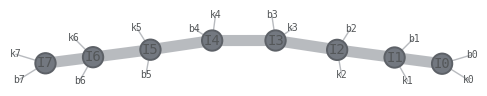

In [101]:
rho.draw()

In [137]:
rho_fuse_maps = [
    ('k', [f'k{i}' for i in range(num_symmetry_sites)]),
    ('b', [f'b{i}' for i in range(num_symmetry_sites)])
]

In [111]:
rho_c = rho.contract()

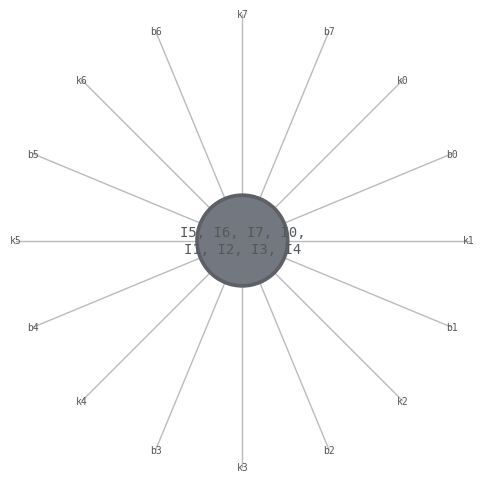

In [112]:
rho_c.draw()

In [113]:
fused_rho = rho_c.fuse(rho_fuse_maps)

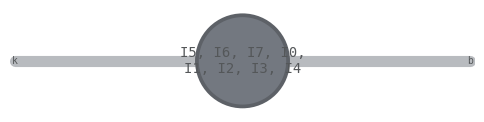

In [114]:
fused_rho.draw()

In [125]:
split_fused_rho = qtn.tensor_core.tensor_split(
    fused_rho,
    left_inds = ['k'],
    absorb=None
)

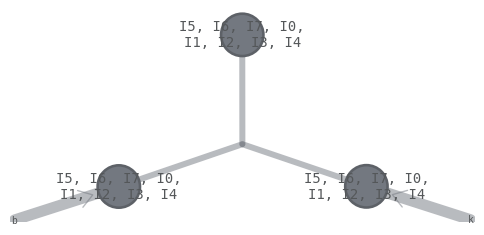

In [126]:
split_fused_rho.draw()

In [127]:
split_fused_rho

TensorNetwork(tensors=3, indices=3)

In [128]:
split_fused_rho.tensors[1].data

array([9.92805087e-01, 1.78316783e-03, 1.78123888e-03, 1.78123887e-03,
       1.77930984e-03, 2.84713177e-05, 2.84713172e-05, 3.19581641e-06,
       3.19580254e-06, 3.19580014e-06, 3.19580013e-06, 5.11423930e-08,
       5.10823601e-08, 5.10823598e-08, 5.10209232e-08, 6.85134378e-09,
       6.48358358e-09, 6.48358319e-09, 6.12008125e-09, 8.16367918e-10])

In [129]:
sub_psi = split_fused_rho.tensors[0]
sub_psi.modify(data=sub_psi.data[:, 0], inds=['k',])

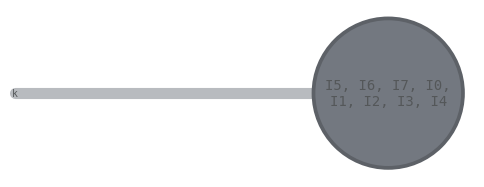

In [130]:
sub_psi.draw()

In [132]:
help(sub_psi.unfuse)

Help on method unfuse in module quimb.tensor.tensor_core:

unfuse(unfuse_map, shape_map, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Reshape single indices into groups of multiple indices
    
    Parameters
    ----------
    unfuse_map : dict_like or sequence of tuples.
        Mapping like: ``{existing_ind: sequence of new inds, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_inds_1), ...]`` in which
        case the output tensor's new inds will be ordered. In both cases
        the new indices are created at the old index's position of the
        tensor's shape
    shape_map : dict_like or sequence of tuples
        Mapping like: ``{old_ind: new_ind_sizes, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_ind_sizes_1), ...]``.
    
    Returns
    -------
    Tensor
        The transposed, reshaped and re-labeled tensor



In [138]:
rho_fuse_maps

[('k', ['k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7']),
 ('b', ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7'])]

In [141]:
sub_psi = sub_psi.unfuse(
    unfuse_map=rho_fuse_maps[:1],
    shape_map={'k': [2,]*num_symmetry_sites}
)

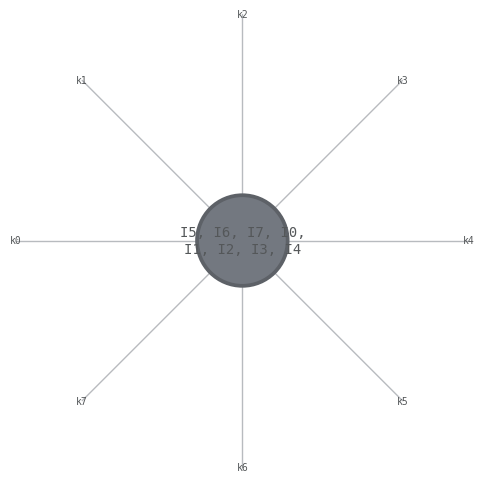

In [142]:
sub_psi.draw()

In [145]:
help(qtn.tensor_builder.MatrixProductState.from_dense)

Help on method from_dense in module quimb.tensor.tensor_1d:

from_dense(psi, dims=2, tags=None, site_ind_id='k{}', site_tag_id='I{}', **split_opts) class method of quimb.tensor.tensor_1d.MatrixProductState
    Create a ``MatrixProductState`` directly from a dense vector
    
    Parameters
    ----------
    psi : array_like
        The dense state to convert to MPS from.
    dims : int or sequence of int
        Physical subsystem dimensions of each site. If a single int, all
        sites have this same dimension, by default, 2.
    tags : str or sequence of str, optional
        Global tags to attach to all tensors.
    site_ind_id : str, optional
        How to index the physical sites, see
        :class:`~quimb.tensor.tensor_1d.MatrixProductState`.
    site_tag_id : str, optional
        How to tag the physical sites, see
        :class:`~quimb.tensor.tensor_1d.MatrixProductState`.
    split_opts
        Supplied to :func:`~quimb.tensor.tensor_core.tensor_split` to
        in ord

In [146]:
sub_psi_mps = qtn.tensor_builder.MatrixProductState.from_dense(
    sub_psi.data,
    dims=2,
)

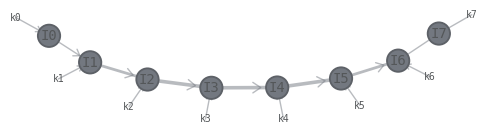

In [147]:
sub_psi_mps.draw()

Now repeat procedure from before.

In [148]:
sub_psi = sub_psi_mps

In [149]:
q_top = sub_psi.copy(deep=True)

In [150]:
for i in range(num_symmetry_sites):
    q_top[i].modify(data=q_top[i].data.conj())
    q_top.gate(
        np_X,
        where=i,
        contract=False,
        inplace=True
    )

In [151]:
q_bottom = (
    sub_psi
    .copy()
    .reindex(index_mapping, inplace=True)
    .conj()
)

In [152]:
tn = (q_top & q_bottom)

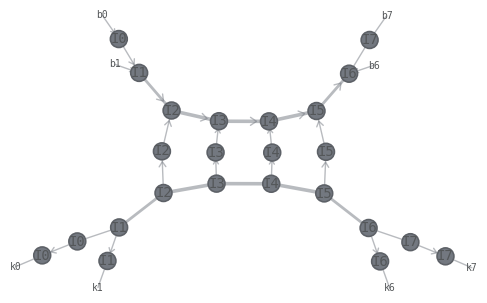

In [153]:
tn.draw()

In [154]:
tnc = tn.contract()

In [156]:
fuse_maps = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites)),
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]

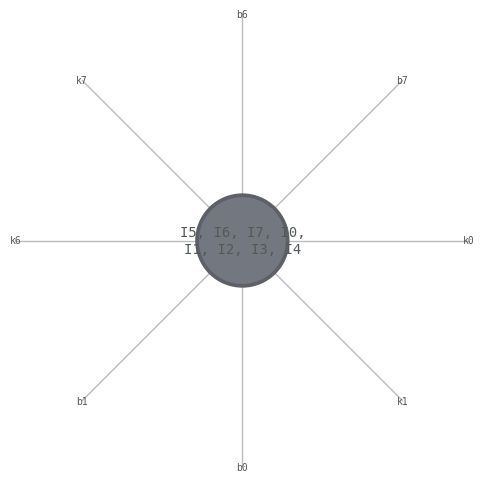

In [157]:
tnc.draw()

In [158]:
tnc.fuse(fuse_maps, inplace=True)

Tensor(shape=(4, 4, 4, 4), inds=('k_left', 'b_left', 'k_right', 'b_right'), tags=oset(['I5', 'I6', 'I7', 'I0', 'I1', 'I2', 'I3', 'I4']))

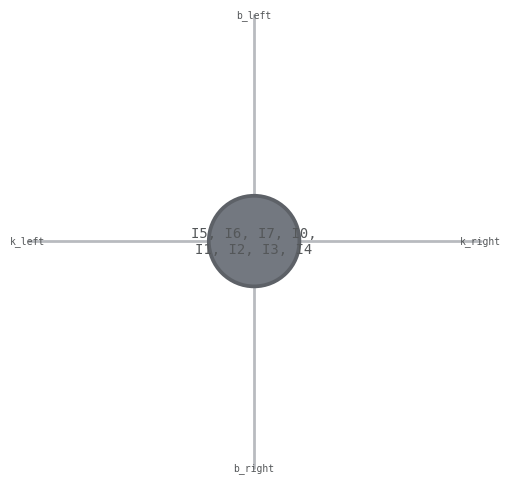

In [159]:
tnc.draw()

In [160]:
split_t = qtn.tensor_core.tensor_split(
    tnc,
    left_inds = ['k_left', 'b_left'],
    absorb=None
)

In [161]:
split_t.tensors[1].data

array([9.92878634e-01, 1.37655682e-04, 1.37655385e-04, 9.37426584e-05,
       4.36420733e-05, 4.36417677e-05, 5.77750850e-06, 2.22273247e-07,
       8.65330153e-09, 1.67836389e-09, 1.67819636e-09, 1.31005581e-09,
       3.84022013e-10, 1.28571278e-10, 1.28506859e-10])

# Conclusion
We're seeing the expected behaviour in the MPS approach, which we are not seeing in the ED approach...!